### Dataset Downloading

In [1]:
from datasets import load_dataset

dataset = load_dataset("google-research-datasets/go_emotions")

print(dataset)

/Users/tejaramidi/anaconda3/envs/emotion_nlp/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})


In [2]:
dataset["train"].to_csv("data/raw/goemotions_train.csv")
dataset["validation"].to_csv("data/raw/goemotions_val.csv")
dataset["test"].to_csv("data/raw/goemotions_test.csv")

Creating CSV from Arrow format: 100%|██████████| 6/6 [00:00<00:00, 162.81ba/s]


450847

In [3]:
import pandas as pd

df = pd.read_csv("data/raw/goemotions_train.csv")
print(df.head())
print(df.columns)

                                                text labels       id
0  My favourite food is anything I didn't have to...   [27]  eebbqej
1  Now if he does off himself, everyone will thin...   [27]  ed00q6i
2                     WHY THE FUCK IS BAYLESS ISOING    [2]  eezlygj
3                        To make her feel threatened   [14]  ed7ypvh
4                             Dirty Southern Wankers    [3]  ed0bdzj
Index(['text', 'labels', 'id'], dtype='object')


In [5]:
emotion_labels = [
"admiration","amusement","anger","annoyance","approval","caring",
"confusion","curiosity","desire","disappointment","disapproval",
"disgust","embarrassment","excitement","fear","gratitude","grief",
"joy","love","nervousness","optimism","pride","realization",
"relief","remorse","sadness","surprise","neutral"
]

In [8]:
import ast

def convert_labels(label_str):
    # Remove brackets
    label_str = label_str.strip("[]")
    
    # Split by space
    indices = label_str.split()
    
    # Convert to integers
    indices = [int(i) for i in indices if i != ""]
    
    return [emotion_labels[i] for i in indices]

df["emotion_names"] = df["labels"].apply(convert_labels)

In [9]:
print(df["labels"].head())
print(df["emotion_names"].head())

0    [27]
1    [27]
2     [2]
3    [14]
4     [3]
Name: labels, dtype: object
0      [neutral]
1      [neutral]
2        [anger]
3         [fear]
4    [annoyance]
Name: emotion_names, dtype: object


In [ ]:
# Removing neutral emotions
df = df[~df["emotion_names"].apply(lambda x: "neutral" in x)]

In [11]:
target_emotions = [
"joy","trust","fear","surprise","sadness",
"disgust","anger","anticipation","love","optimism","pessimism"
]

In [12]:
# Plutchik’s model
mapping = {
"admiration": "trust",
"approval": "trust",
"gratitude": "trust",

"caring": "love",
"love": "love",

"joy": "joy",
"amusement": "joy",
"excitement": "joy",
"relief": "joy",
"pride": "joy",

"optimism": "optimism",

"desire": "anticipation",
"curiosity": "anticipation",

"fear": "fear",
"nervousness": "fear",

"anger": "anger",
"annoyance": "anger",
"disapproval": "anger",

"disgust": "disgust",

"sadness": "sadness",
"grief": "sadness",
"remorse": "sadness",

"disappointment": "pessimism",

"confusion": "surprise",
"realization": "surprise",
"surprise": "surprise"
}

In [13]:
def map_to_target(emotions):
    mapped = []
    for e in emotions:
        if e in mapping:
            mapped.append(mapping[e])
    return list(set(mapped))

df["mapped_emotions"] = df["emotion_names"].apply(map_to_target)

In [14]:
df = df[df["mapped_emotions"].map(len) > 0]

In [15]:
import numpy as np

def multi_hot(labels):
    vec = np.zeros(len(target_emotions))
    for l in labels:
        if l in target_emotions:
            vec[target_emotions.index(l)] = 1
    return vec

df["label_vector"] = df["mapped_emotions"].apply(multi_hot)

In [16]:
print(df[["text", "mapped_emotions", "label_vector"]].head())

                                                text mapped_emotions  \
2                     WHY THE FUCK IS BAYLESS ISOING         [anger]   
3                        To make her feel threatened          [fear]   
4                             Dirty Southern Wankers         [anger]   
5  OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe...      [surprise]   
6  Yes I heard abt the f bombs! That has to be wh...         [trust]   

                                        label_vector  
2  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ...  
3  [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...  
4  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ...  
5  [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...  
6  [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...  


In [18]:
print(df.shape)
print(df["mapped_emotions"].head())

(28988, 6)
2       [anger]
3        [fear]
4       [anger]
5    [surprise]
6       [trust]
Name: mapped_emotions, dtype: object


### Dataset Cleaning

In [19]:
import re
import unicodedata

def clean_text(text):
    # Lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    
    # Remove mentions (@user)
    text = re.sub(r"@\w+", "", text)
    
    # Remove hashtags (keep word)
    text = re.sub(r"#(\w+)", r"\1", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    # Unicode normalization
    text = unicodedata.normalize("NFC", text)
    
    return text

df["clean_text"] = df["text"].apply(clean_text)

In [23]:
# Token Length
df["word_count"] = df["clean_text"].apply(lambda x: len(x.split()))

# Filtering
df = df[(df["word_count"] >= 5) & (df["word_count"] <= 50)]

# Remove unwanted rows
df = df[df["clean_text"].str.strip() != ""]
df = df.dropna()

# Duplicates removing
df = df.drop_duplicates(subset=["clean_text"])
df = df[df["mapped_emotions"].map(len) > 0]

In [24]:
def remove_conflicts(labels):
    if "joy" in labels and "sadness" in labels:
        return False
    return True

df = df[df["mapped_emotions"].apply(remove_conflicts)]

In [25]:
print("Final shape:", df.shape)
print(df[["clean_text", "mapped_emotions"]].head())

Final shape: (25721, 8)
                                          clean_text           mapped_emotions
2                     why the fuck is bayless isoing                   [anger]
3                        to make her feel threatened                    [fear]
5  omg peyton isn't good enough to help us in the...                [surprise]
6  yes i heard abt the f bombs! that has to be wh...                   [trust]
7  we need more boards and to create a bit more s...  [optimism, anticipation]


In [27]:
df_final = df[["clean_text", "mapped_emotions", "label_vector"]]
df_final.to_csv("data/processed/goemotions_cleaned.csv", index=False)

### Dataset Class Balance

In [28]:
from collections import Counter

all_labels = []

for labels in df["mapped_emotions"]:
    all_labels.extend(labels)

counter = Counter(all_labels)

print(counter)

Counter({'trust': 7608, 'anger': 4745, 'joy': 3942, 'surprise': 3072, 'love': 2670, 'anticipation': 2513, 'sadness': 1600, 'optimism': 1479, 'pessimism': 1137, 'disgust': 684, 'fear': 625})


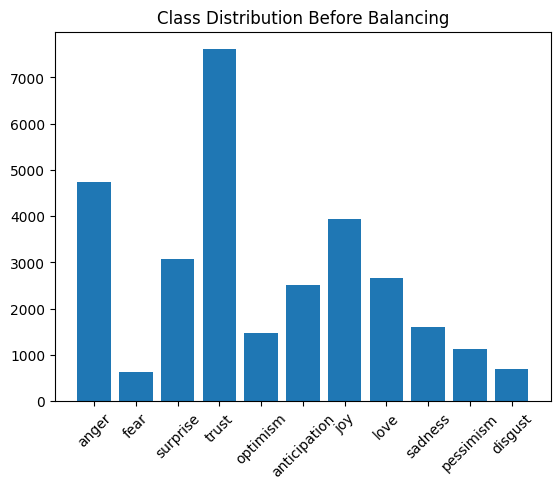

In [30]:
import matplotlib.pyplot as plt

labels = list(counter.keys())
values = list(counter.values())

plt.figure()
plt.bar(labels, values)
plt.xticks(rotation=45)
plt.title("Class Distribution Before Balancing")
plt.show()

In [37]:
min_target = 1500
max_target = 3000

from sklearn.utils import resample

balanced_df = df.copy()

for label, count in counter.items():
    
    if count < min_target:
        subset = df[df["mapped_emotions"].apply(lambda x: label in x)]
        
        needed = min_target - count
        
        oversampled = resample(
            subset,
            replace=True,
            n_samples=needed,
            random_state=42
        )
        
        balanced_df = pd.concat([balanced_df, oversampled])

In [38]:
if counter["trust"] > max_target:
    trust_subset = balanced_df[balanced_df["mapped_emotions"].apply(lambda x: "trust" in x)]
    
    trust_subset = trust_subset.sample(max_target, random_state=42)
    
    non_trust = balanced_df[~balanced_df["mapped_emotions"].apply(lambda x: "trust" in x)]
    
    balanced_df = pd.concat([trust_subset, non_trust])

In [39]:
from collections import Counter

all_labels = []
for labels in balanced_df["mapped_emotions"]:
    all_labels.extend(labels)

print(Counter(all_labels))

Counter({'anger': 4924, 'joy': 3650, 'trust': 3000, 'surprise': 2972, 'anticipation': 2451, 'love': 2443, 'sadness': 1654, 'pessimism': 1492, 'disgust': 1482, 'fear': 1481, 'optimism': 1361})


In [41]:
final_df = balanced_df[["clean_text", "mapped_emotions", "label_vector"]]

final_df.to_csv("data/processed/goemotions_balanced.csv", index=False)

### Dataset Translations(English --> Other --> English)

In [ ]:
from huggingface_hub import login

import os
from dotenv import load_dotenv

load_dotenv()
login(os.getenv("HF_TOKEN"))

In [3]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

model_name = "ai4bharat/indictrans2-en-indic-1B"

tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    trust_remote_code=True,
    use_fast=False
)

model = AutoModelForSeq2SeqLM.from_pretrained(
    model_name,
    trust_remote_code=True
)

device = "mps" if torch.backends.mps.is_available() else "cpu"

model = model.to(device)

print("Using device:", device)

model.eval()

print("Model loaded")

/Users/tejaramidi/anaconda3/envs/emotion_nlp/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.
0it [00:00, ?it/s]
/Users/tejaramidi/anaconda3/envs/emotion_nlp/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
A new version of the following files was downloaded from https://huggingface.co/ai4bharat/indictrans2-en-indic-1B:
- modeling_indictrans.py
. Make sure t

Using device: mps
Model loaded


In [8]:
model = model.to("cpu")

def batch_translate(texts, target_lang_code):
    
    src_lang = "eng_Latn"
    
    inputs = [f"{src_lang} {target_lang_code} {t}" for t in texts]
    
    tokenized = tokenizer(
        inputs,
        return_tensors="pt",
        padding=True,
        truncation=True
    )
    
    with torch.no_grad():
        outputs = model.generate(
            **tokenized,
            max_length=128,
            num_beams=5,
            do_sample=False
        )
    
    return [tokenizer.decode(o, skip_special_tokens=True) for o in outputs]

In [10]:
from indic_transliteration import sanscript
from indic_transliteration.sanscript import transliterate

def fix_script(text, lang):
    if lang == "telugu":
        return transliterate(text, sanscript.DEVANAGARI, sanscript.TELUGU)
    elif lang == "malayalam":
        return transliterate(text, sanscript.DEVANAGARI, sanscript.MALAYALAM)
    return text

In [11]:
import pandas as pd

df = pd.read_csv("data/processed/goemotions_balanced.csv")

In [17]:
df1 = pd.read_csv("progress.csv")
start_idx = df1[df1["text_hi"].isna()].index[0]
print("Resuming from:", start_idx)

Resuming from: 2408


In [18]:
# from tqdm import tqdm

# batch_size = 8

# for i in tqdm(range(start_idx, len(df), batch_size)):
    
#     batch = df["clean_text"][i:i+batch_size].tolist()
    
#     hi = batch_translate(batch, "hin_Deva")
#     te = batch_translate(batch, "tel_Telu")
#     ml = batch_translate(batch, "mal_Mlym")
    
#     # Fix scripts
#     te = [fix_script(x, "telugu") for x in te]
#     ml = [fix_script(x, "malayalam") for x in ml]
    
#     df.loc[i:i+batch_size-1, "text_hi"] = hi
#     df.loc[i:i+batch_size-1, "text_te"] = te
#     df.loc[i:i+batch_size-1, "text_ml"] = ml
    
#     # Save progress
#     if i % 50 == 0:
#         df.to_csv("progress.csv", index=False)

In [19]:
# df.to_csv("translated_dataset.csv", index=False)

In [20]:
#Final shape: (25721, 8)

In [29]:
import pandas as pd

df = pd.read_csv("translated_dataset.csv")

print(df.shape)
print(df.head())

(23102, 6)
                                          clean_text  \
0  yes it is i’m 99.9% sure! thank you! enjoy you...   
1                           oh you got me. good one.   
2  you got it, just keep doing whatever you were ...   
3  > i'll only debate subjects i'm knowledgable o...   
4  thank you, i need it. i am currently trying to...   

             mapped_emotions                        label_vector  \
0                  ['trust']  [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]   
1                  ['trust']  [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]   
2                  ['trust']  [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]   
3         ['anger', 'trust']  [0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0.]   
4  ['trust', 'anticipation']  [0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0.]   

                                             text_hi  \
0  हां, यह 99.9 % निश्चित है, धन्यवाद, अपने सोने ...   
1                    ओह तुम मुझे मिल गया. अच्छा एक ।   
2  आप समझ गए हैं कि आप पिछले 20 - जो भी दिन कर रह...   
3  > मैं केवल उन वि

In [30]:
print(df.columns)

Index(['clean_text', 'mapped_emotions', 'label_vector', 'text_hi', 'text_te',
       'text_ml'],
      dtype='object')


In [31]:
print(df.isna().sum())

clean_text         0
mapped_emotions    0
label_vector       0
text_hi            0
text_te            0
text_ml            0
dtype: int64


In [32]:
# Drop duplicates
df = df.drop_duplicates(subset=["clean_text"])

In [33]:
import re

def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+", "", text)  # remove links
    text = re.sub(r"\s+", " ", text)     # remove extra spaces
    return text.strip()

df["clean_text"] = df["clean_text"].apply(clean_text)
df["text_hi"] = df["text_hi"].apply(clean_text)
df["text_te"] = df["text_te"].apply(clean_text)
df["text_ml"] = df["text_ml"].apply(clean_text)

In [34]:
print(df["label_vector"].iloc[0])

[0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [35]:
MAX_LEN = 300

df["clean_text"] = df["clean_text"].apply(lambda x: x[:MAX_LEN])
df["text_hi"] = df["text_hi"].apply(lambda x: x[:MAX_LEN])
df["text_te"] = df["text_te"].apply(lambda x: x[:MAX_LEN])
df["text_ml"] = df["text_ml"].apply(lambda x: x[:MAX_LEN])

In [36]:
df_en = df[["clean_text", "label_vector"]].rename(columns={"clean_text": "text"})
df_hi = df[["text_hi", "label_vector"]].rename(columns={"text_hi": "text"})
df_te = df[["text_te", "label_vector"]].rename(columns={"text_te": "text"})
df_ml = df[["text_ml", "label_vector"]].rename(columns={"text_ml": "text"})

final_df = pd.concat([df_en, df_hi, df_te, df_ml], ignore_index=True)

print(final_df.shape)

(84380, 2)


In [39]:
print(final_df.head(10))

                                                text  \
0  yes it is i’m 99.9% sure! thank you! enjoy you...   
1                           oh you got me. good one.   
2  you got it, just keep doing whatever you were ...   
3  > i'll only debate subjects i'm knowledgable o...   
4  thank you, i need it. i am currently trying to...   
5  my day gets better every time a poser is expos...   
6  these people seen so much in their lifetimes. ...   
7  <3 btw it does sound like you're generally doi...   
8  [name] will be gone. although i think end of t...   
9  should be best right now. speculating on what ...   

                         label_vector  
0  [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]  
1  [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]  
2  [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]  
3  [0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0.]  
4  [0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0.]  
5  [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]  
6  [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]  
7  [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]  
8  [0. 1. 0. 0. 0. 0. 0

In [40]:
print(final_df.columns)

Index(['text', 'label_vector'], dtype='object')


In [41]:
final_df.to_csv("final_multilingual_dataset.csv", index=False)